In [1]:
import math
from urllib.request import urlopen, Request

import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from mplsoccer import VerticalPitch, Sbopen, FontManager, inset_image

# data parser, fonts and path effects for giving the font an edge
parser = Sbopen()
roboto_bold = FontManager(
    'https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/RobotoSlab%5Bwght%5D.ttf')
path_eff = [path_effects.Stroke(linewidth=3, foreground='white'),
            path_effects.Normal()]


In [2]:
parser = Sbopen()
event, related, freeze, tactics = parser.event(3857283)

# Starting XI for Morocco
starting_xi_event = event.loc[
    (event['type_name'] == 'Starting XI') &
    (event['team_name'] == 'Morocco'),
    ['id', 'tactics_formation']
]

starting_xi = tactics.merge(starting_xi_event, on='id')

# Morocco WC 2022 short names
player_short_names = {
    'Yassine Bounou': 'Bono',
    'Achraf Hakimi Mouh': 'Hakimi',
    'Noussair Mazraoui': 'Mazraoui',
    'Romain Saïss': 'Saïss',
    'Jawad El Yamiq': 'El Yamiq',
    'Yahia Attiyat Allah': 'Attiyat Allah',
    'Sofyan Amrabat': 'Amrabat',
    'Azzedine Ounahi': 'Ounahi',
    'Hakim Ziyech': 'Ziyech',
    'Abdelhamid Sabiri': 'Sabiri',
    'Youssef En-Nesyri': 'En-Nesyri',
}
starting_xi['player_name'] = starting_xi['player_name'].replace(player_short_names)

# Successful ball receipts from starting XI only
ball_receipts = event.loc[
    (event['type_name'] == 'Ball Receipt') &
    (event['outcome_name'].isnull()) &
    (event['player_id'].isin(starting_xi['player_id'])),
    ['player_id', 'x', 'y']
]

# Merge starting positions
event = ball_receipts.merge(starting_xi, on='player_id')
formation = event['tactics_formation'].iloc[0]

print(f"Formation: {formation}")
print(f"Players found: {event['player_name'].nunique()}")

Formation: 433
Players found: 11


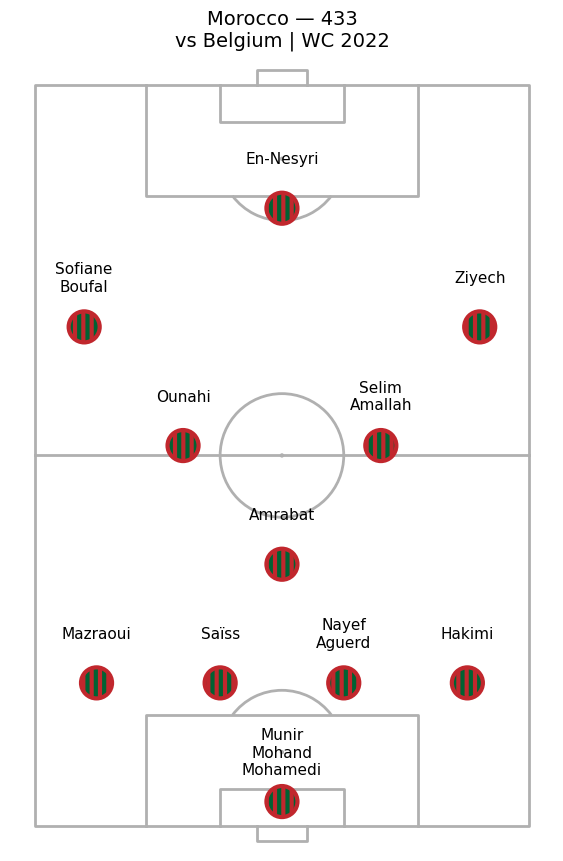

In [10]:
pitch = VerticalPitch(goal_type='box')
fig, ax = pitch.draw(figsize=(6, 8.72))

# Text labels
ax_text = pitch.formation(
    formation,
    positions=starting_xi.position_id,
    kind='text',
    text=starting_xi.player_name.str.replace(' ', '\n'),
    va='center',
    ha='center',
    fontsize=11,
    ax=ax
)

# Scatter markers (Barcelona colors → change to Morocco colors)
mpl.rcParams['hatch.linewidth'] = 3
mpl.rcParams['hatch.color'] = '#006233'  # Morocco green (was Barcelona red #a50044)

ax_scatter = pitch.formation(
    formation,
    positions=starting_xi.position_id,
    kind='scatter',
    c='#C1272D',           # Morocco red (was Barcelona blue #004d98)
    hatch='||',
    linewidth=3,
    s=500,
    xoffset=-8,
    ax=ax
)

ax.set_title(f"Morocco — {formation}\nvs Belgium | WC 2022", size=14, pad=10)
plt.tight_layout()
plt.show()